# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [6]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [8]:
label_names=emotion_dataset['train'].features['label'].names

In [9]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [12]:
df_train=pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)

df_test=pd.DataFrame(
    {
        'text':test_text,
        'lebel':[label_names[i] for i in test_label]
    }
)

In [13]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [15]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

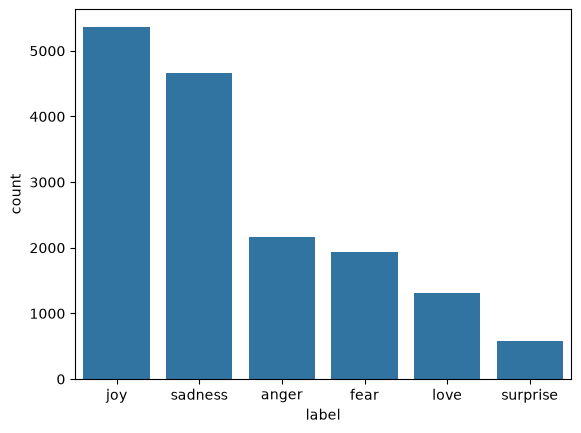

In [16]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [17]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000

tokenizer=Tokenizer(num_words=max_words,oov_token='<uk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_label))
num_classes

print(f"Vocabulary Size : {len(tokenizer.word_index)}")
print(f"The Sentence Length : {padded_train_sequence.shape[1]}")

Vocabulary Size : 15213
The Sentence Length : 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.